In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

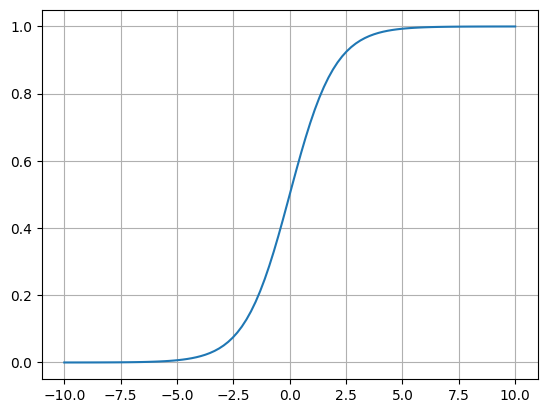

In [2]:
x = np.linspace(-10,10, 100)
y=1/(1+np.exp(-x))
 
# Plot the graph
plt.plot(x, y)
plt.plot()
plt.grid(True)


![img](https://miro.medium.com/v2/resize:fit:828/format:webp/1*HwoyV8PkILVCSQdlc-VrrA.png)!

The sigmoid function g(z) takes features and weights z as an input and returns a result between 0 and 1. The output of the sigmoid function is an actual prediction ŷ.

![img](https://miro.medium.com/v2/resize:fit:828/format:webp/1*mWyU3Xo_pjJpDBnnp789Sw.png)

After the model made a prediction, we can evaluate the result with a cross-entropy loss function:

![img](https://miro.medium.com/v2/resize:fit:828/format:webp/1*h9idzK6YjMKKxfCl-Zq8eA.png)

In [3]:
class logisticRegression:

    def __init__(self,lr=0.001,n_iters=1000):
        self.lr= lr
        self.n_iters= n_iters
        self.weights= None
        self.bias=None

    def fit(self,X,y):
    #init parameters
        n_samples,n_features=X.shape
        self.weights=np.zeros(n_features) 
        self.bias=0

        #gradient descent
        for _ in range(self.n_iters):
            linear_model= np.dot(X, self.weights)+self.bias
            y_predicted=self._sigmoid(linear_model)

            dw= (1/n_samples)*np.dot(X.T,(y_predicted-y))
            db=(1/n_samples)* np.sum(y_predicted-y)

            self.weights-=self.lr*dw
            self.bias-= self.lr*db

    def predict(self,X):
        linear_model=np.dot(X, self.weights) + self.bias
        y_predicted= self._sigmoid(linear_model)
        y_predicted_cls=[1 if i>0.5 else 0 for i in y_predicted]
        return y_predicted_cls   

    def _sigmoid(self,x):
        return 1/(1+np.exp(-x))   

    

In [4]:
bc=datasets.load_breast_cancer()
X, y = bc.data ,bc.target

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1234)

In [6]:
def accuracy(y_true,y_pred):
    accuracy =np.sum(y_true == y_pred)/len(y_true)
    return(accuracy)

In [7]:
regressor=logisticRegression(lr=0.001,n_iters=1000)
regressor.fit(X_train,y_train)
predictions= regressor.predict(X_test) 

C:\Users\UMESH SOLANKI\AppData\Local\Temp\ipykernel_6212\2871119914.py:33: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


In [8]:
print("LR classification accuracy:",accuracy(y_test,predictions))

LR classification accuracy: 0.8947368421052632
